In [5]:
# inputs            x_1, x_2
# actual output     y
# middle layer      y_
# predicted output  f_y
# weights           w_1, w_2
# bias              b

# taking weights and bias at starting = 0
# new weight = old weight + (learning rate)*(x)*(y)
# new bias = old bias + (learning rate)*(y)

In [7]:
def q_1():
    inputs=[(0,0), (0,1), (1,0), (1,1)]
    actual_outputs=(0,0,0,1)
    y_=[0,0,0,0]
    weights=[1,1]
    bias=1
    learning_rate=1
    predicted_outputs=[0,0,0,0]
    # using step function as activation function
    # run loop for all the tuples in the table check if predicted and actual mismatch anywhere
    mistake=True
    epoch=1
    while(mistake):
        print(f'Epoch: {epoch}')
        epoch+=1
        mistake=False
        for i in range(len(inputs)):
            y_[i]=inputs[i][0]*weights[0] + inputs[i][1]*weights[1] + bias
            predicted_outputs[i]=1 if y_[i]>=3 else 0
            if actual_outputs[i]!=predicted_outputs[i]:
                mistake=True
                weights[0]+=learning_rate*inputs[i][0]*actual_outputs[i]
                bias+=learning_rate*actual_outputs[i]
        # after all iterations for all inputs check if anywhere we have found mistake run loop again
q_1()

Epoch: 1


In [8]:
import pandas as pd
file=pd.read_csv('data.csv')

In [24]:
file.sample(10)

,race_id,horse_id,1-101,1-102,1-103,1-104,1-105,1-106,1-107,1-108,...,3-132,4-105,4-109,4-110,4-114,4-115,4-116,4-117,calc_position,price
29630,555866,758306,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,0.170000,...,-0.73,-0.089305,-0.530,0.180,0.69,0.65,0.76,1.37,3.0,2.88
13868,524114,711480,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,-1.910000,...,0.36,-0.590000,0.920,0.950,-1.03,-0.99,-1.05,0.22,10.0,11.00
25106,545106,734059,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,-0.010000,...,2.55,-0.570000,-0.130,-0.150,0.68,0.93,1.05,0.89,7.0,15.00
12677,521697,711769,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,0.590000,...,-0.87,-0.100000,1.440,1.740,-1.64,-1.59,-1.95,0.13,13.0,51.00
31450,559676,425302,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,-0.650000,...,0.34,1.070000,-1.240,-0.950,1.39,1.43,1.48,1.93,13.0,10.00
9117,514545,728931,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,0.980000,...,-0.42,2.380000,-1.000,-1.300,1.33,1.30,1.52,0.62,8.0,26.00
21776,539490,773763,-0.610000,-0.580000,-0.370000,-1.82000,-1.090000,-1.300000,-0.74000,0.750000,...,-0.44,3.690000,-1.080,-1.740,1.56,1.64,1.47,3.05,1.0,11.00
8778,514052,660139,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,0.000199,...,-0.45,-0.089305,-0.285,-0.285,-0.18,-0.33,-0.44,-0.40,1.0,2.90
31305,559392,649158,-0.560000,-0.530000,-0.530000,-0.71000,-0.710000,-0.710000,-0.71000,1.220000,...,0.00,0.120000,0.160,0.350,-0.23,-0.45,-0.38,0.22,6.0,9.00
30404,557495,792700,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,1.380000,...,-0.17,-0.510000,-1.000,-1.350,1.43,1.28,1.29,-0.25,4.0,11.00


In [25]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34505 entries, 0 to 34504
Data columns (total 64 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   race_id        34505 non-null  int64  
 1   horse_id       34505 non-null  int64  
 2   1-101          34505 non-null  float64
 3   1-102          34505 non-null  float64
 4   1-103          34505 non-null  float64
 5   1-104          34505 non-null  float64
 6   1-105          34505 non-null  float64
 7   1-106          34505 non-null  float64
 8   1-107          34505 non-null  float64
 9   1-108          34505 non-null  float64
 10  1-109          34505 non-null  float64
 11  1-110          34505 non-null  float64
 12  1-111          34505 non-null  float64
 13  1-112          34505 non-null  float64
 14  1-113          34505 non-null  float64
 15  1-114          34505 non-null  float64
 16  1-115          34505 non-null  float64
 17  1-116          34505 non-null  float64
 18  1-117 

In [11]:
file.isnull().sum()

,0
race_id,0
horse_id,0
1-101,22703
1-102,22687
1-103,22687
...,...
4-115,3484
4-116,4011
4-117,3150
calc_position,5


In [15]:
# filled null values with mean
null_columns=list()
for i in file.columns:
    if file[i].hasnans:
        null_columns.append(i)
print(null_columns)

['1-101', '1-102', '1-103', '1-104', '1-105', '1-106', '1-107', '1-108', '1-109', '1-110', '1-111', '1-112', '1-113', '1-114', '1-115', '1-116', '1-117', '1-118', '1-119', '1-120', '1-121', '1-122', '1-123', '1-124', '1-125', '1-126', '1-127', '1-128', '1-129', '3-101', '3-102', '3-103', '3-104', '3-105', '3-106', '3-107', '3-109', '3-110', '3-114', '3-115', '3-116', '3-117', '3-118', '3-119', '3-120', '3-121', '3-122', '3-123', '3-124', '3-125', '3-130', '3-131', '3-132', '4-105', '4-109', '4-110', '4-114', '4-115', '4-116', '4-117', 'calc_position', 'price']


In [16]:
for column in null_columns:
    file[column]=file[column].fillna(file[column].mean())

In [23]:
# how many columns have null values now
file.isnull().sum().sum()

np.int64(0)

In [28]:
# label modification
label='calc_position'
file[label]=(file[label]==1).astype(int)

In [30]:
file.sample(10)

,race_id,horse_id,1-101,1-102,1-103,1-104,1-105,1-106,1-107,1-108,...,3-132,4-105,4-109,4-110,4-114,4-115,4-116,4-117,calc_position,price
16333,530725,782527,0.400000,0.290000,-0.110000,-0.04885,-0.065896,-0.054214,-0.06563,-0.17,...,-0.62,-0.660000,0.86,0.52,-0.39,-0.59,-0.74,-1.12,0,15.00
13818,524071,726918,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,-2.09,...,-1.30,-0.440000,1.36,1.63,-1.51,-1.44,-0.84,-0.62,0,8.50
33753,563320,671912,-0.470000,-0.550000,-0.560000,0.00000,0.000000,0.000000,0.00000,0.85,...,-0.70,-0.210000,1.28,0.88,-1.24,-1.41,-1.05,-0.33,0,34.00
15771,529128,654905,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,0.24,...,-1.10,-0.089305,0.71,0.73,0.27,0.17,0.94,0.80,0,5.50
16864,531993,650482,0.000000,0.000000,0.000000,-0.04885,-0.065896,-0.054214,-0.06563,-0.56,...,1.54,0.510000,-0.94,0.00,-0.31,-1.23,-0.25,-0.91,1,4.50
30446,557538,750009,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,-0.07,...,1.79,-0.460000,0.41,0.82,-0.74,-0.72,-0.30,0.72,0,3.25
28649,553762,714880,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,-0.50,...,1.36,0.580000,0.91,0.65,-0.87,-0.68,-0.61,-1.40,0,4.00
7484,512105,716082,-1.200000,-0.900000,-0.510000,-0.28000,-0.600000,2.090000,2.50000,-2.44,...,-0.72,0.980000,-0.92,-0.41,0.71,0.53,0.29,1.25,0,9.50
19718,536473,790239,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,-0.99,...,-0.55,0.030000,-0.70,-1.04,1.29,1.13,1.06,0.23,0,34.00
32842,561875,746942,-0.090000,0.440000,0.250000,0.00000,0.000000,0.000000,0.00000,0.32,...,0.74,-0.205000,0.62,0.43,-0.45,0.00,-0.53,-0.94,1,2.38


<Axes: xlabel='calc_position'>

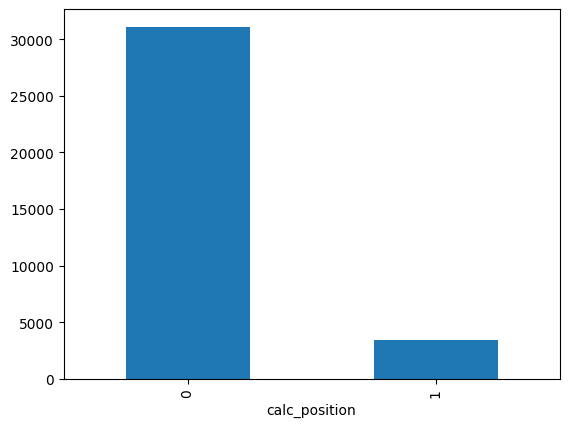

In [31]:
file[label].value_counts().plot(kind='bar')

In [32]:
# one hot encoding
file_encoded = pd.get_dummies(file, columns=['race_id', 'horse_id'])

In [33]:
file_encoded.sample(10)

,1-101,1-102,1-103,1-104,1-105,1-106,1-107,1-108,1-109,1-110,...,horse_id_822007,horse_id_822008,horse_id_822009,horse_id_822012,horse_id_822079,horse_id_822211,horse_id_822346,horse_id_822347,horse_id_822623,horse_id_846253
15288,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,0.000199,-0.008351,-0.00669,...,False,False,False,False,False,False,False,False,False,False
33706,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,0.640000,0.470000,1.26000,...,False,False,False,False,False,False,False,False,False,False
5135,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,-0.030000,0.280000,0.29000,...,False,False,False,False,False,False,False,False,False,False
18902,-0.130000,-0.100000,0.210000,-0.06000,0.630000,-0.100000,-0.10000,-0.750000,0.430000,0.65000,...,False,False,False,False,False,False,False,False,False,False
31643,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,1.220000,-0.780000,-0.74000,...,False,False,False,False,False,False,False,False,False,False
23700,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,0.000199,-0.008351,-0.00669,...,False,False,False,False,False,False,False,False,False,False
34229,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,-0.430000,-0.730000,0.44000,...,False,False,False,False,False,False,False,False,False,False
29268,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,-0.570000,1.590000,1.59000,...,False,False,False,False,False,False,False,False,False,False
21610,-0.040785,-0.040666,-0.038634,-0.04885,-0.065896,-0.054214,-0.06563,0.000199,-0.008351,-0.00669,...,False,False,False,False,False,False,False,False,False,False
10080,-0.570000,-0.530000,-0.500000,0.00000,0.000000,0.000000,0.00000,0.570000,0.120000,0.36000,...,False,False,False,False,False,False,False,False,False,False


In [35]:
"""
AL-2002: Artificial Intelligence Lab — Lab Manual 10
Question 2: Horse Racing Dataset Analysis
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════════
# STEP 1: Load the Dataset
# ═══════════════════════════════════════════════════════════════
print("=" * 65)
print("  STEP 1: Load the Dataset")
print("=" * 65)

df = pd.read_csv('data.csv')

print(f"  Shape        : {df.shape}")
print(f"  Rows         : {df.shape[0]:,}")
print(f"  Columns      : {df.shape[1]}")
print(f"\n  First 3 rows:\n")
print(df.head(3).to_string())

# ═══════════════════════════════════════════════════════════════
# STEP 2: Clean the Dataset
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  STEP 2: Clean the Dataset")
print("=" * 65)

# --- 2a. Missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing'] > 0].sort_values('Missing %', ascending=False)

print(f"\n  Columns with missing values ({len(missing_report)} out of {df.shape[1]}):")
print(missing_report.to_string())

# Drop columns where more than 50% values are missing
high_missing_cols = missing_report[missing_report['Missing %'] > 50].index.tolist()
print(f"\n  Dropping {len(high_missing_cols)} columns with >50% missing values:")
print(f"  {high_missing_cols}")
df.drop(columns=high_missing_cols, inplace=True)

# Fill remaining missing values with column median
remaining_missing = df.isnull().sum().sum()
print(f"\n  Remaining missing cells before median-fill : {remaining_missing:,}")
df.fillna(df.median(numeric_only=True), inplace=True)
print(f"  Missing cells after  median-fill           : {df.isnull().sum().sum()}")

# --- 2b. Duplicates ---
dupes = df.duplicated().sum()
print(f"\n  Duplicate rows: {dupes}")
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"  Removed duplicates. New shape: {df.shape}")

# --- 2c. Outliers in 'price' ---
q1, q3 = df['price'].quantile(0.25), df['price'].quantile(0.75)
iqr = q3 - q1
upper_cap = q3 + 3 * iqr
outliers_before = (df['price'] > upper_cap).sum()
print(f"\n  Price outliers above {upper_cap:.0f}: {outliers_before:,}")
df['price'] = df['price'].clip(upper=upper_cap)
print(f"  Price capped at {upper_cap:.0f} (IQR method, 3× fence)")

print(f"\n  Clean dataset shape: {df.shape}")

# ═══════════════════════════════════════════════════════════════
# STEP 3: Convert Labels into 0 or 1  (Winner / Non-winner)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  STEP 3: Convert Labels into 0 or 1")
print("=" * 65)

# calc_position == 1  →  Winner (1)
# calc_position  > 1  →  Non-winner (0)
df['label'] = (df['calc_position'] == 1).astype(int)

print(f"\n  Mapping: calc_position == 1  →  label = 1  (Winner)")
print(f"           calc_position  > 1  →  label = 0  (Non-winner)")
print(f"\n  Label distribution:")
print(df['label'].value_counts().rename({0: 'Non-winner (0)', 1: 'Winner (1)'}).to_string())
print(f"\n  Win rate: {df['label'].mean()*100:.2f}%")

# ═══════════════════════════════════════════════════════════════
# STEP 4: Exploratory Data Analysis (EDA) Plots
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  STEP 4: Exploratory Data Analysis")
print("=" * 65)

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Horse Racing Dataset — Exploratory Data Analysis", fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- Plot 1: Label distribution (bar) ---
ax1 = fig.add_subplot(gs[0, 0])
counts = df['label'].value_counts().sort_index()
bars = ax1.bar(['Non-winner (0)', 'Winner (1)'], counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Label Distribution (Winners vs Non-Winners)', fontsize=10)
ax1.set_ylabel('Count')
ax1.set_ylim(0, counts.max() * 1.15)

# --- Plot 2: calc_position frequency ---
ax2 = fig.add_subplot(gs[0, 1])
pos_counts = df['calc_position'].value_counts().sort_index().head(15)
ax2.bar(pos_counts.index.astype(int), pos_counts.values, color='steelblue', edgecolor='black')
ax2.set_title('Finishing Position Frequency (Top 15)', fontsize=10)
ax2.set_xlabel('Finishing Position')
ax2.set_ylabel('Count')

# --- Plot 3: Price distribution ---
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df['price'], bins=40, color='#9b59b6', edgecolor='black', alpha=0.8)
ax3.set_title('Price (Odds) Distribution', fontsize=10)
ax3.set_xlabel('Price')
ax3.set_ylabel('Frequency')

# --- Plot 4: Price by Winner vs Non-winner (box) ---
ax4 = fig.add_subplot(gs[1, 0])
winners     = df[df['label'] == 1]['price']
non_winners = df[df['label'] == 0]['price']
ax4.boxplot([non_winners, winners], labels=['Non-winner', 'Winner'],
            patch_artist=True,
            boxprops=dict(facecolor='#f39c12', color='black'),
            medianprops=dict(color='red', linewidth=2))
ax4.set_title('Price Distribution by Outcome', fontsize=10)
ax4.set_ylabel('Price (Odds)')

# --- Plot 5: Missing-value heatmap (after cleaning, show remaining) ---
ax5 = fig.add_subplot(gs[1, 1])
feature_cols = [c for c in df.columns if c not in ['race_id', 'horse_id', 'calc_position', 'label', 'price']]
null_pct = df[feature_cols].isnull().mean() * 100
ax5.bar(range(len(null_pct)), null_pct.values, color='#e74c3c')
ax5.set_title('Remaining Missing % per Feature Column', fontsize=10)
ax5.set_xlabel('Feature Index')
ax5.set_ylabel('Missing %')
ax5.set_ylim(0, max(null_pct.max() + 5, 5))

# --- Plot 6: Correlation of features with label ---
ax6 = fig.add_subplot(gs[1, 2])
corr = df[feature_cols + ['label']].corr()['label'].drop('label').sort_values()
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr.values]
ax6.barh(range(len(corr)), corr.values, color=colors)
ax6.set_yticks(range(len(corr)))
ax6.set_yticklabels(corr.index, fontsize=7)
ax6.axvline(0, color='black', linewidth=0.8)
ax6.set_title('Feature Correlation with Label', fontsize=10)
ax6.set_xlabel('Pearson Correlation')

# --- Plot 7: Unique horses per race ---
ax7 = fig.add_subplot(gs[2, 0])
horses_per_race = df.groupby('race_id')['horse_id'].nunique()
ax7.hist(horses_per_race, bins=20, color='#1abc9c', edgecolor='black', alpha=0.85)
ax7.set_title('Horses per Race', fontsize=10)
ax7.set_xlabel('# Horses')
ax7.set_ylabel('# Races')

# --- Plot 8: Winner price vs non-winner price (violin) ---
ax8 = fig.add_subplot(gs[2, 1])
parts = ax8.violinplot([non_winners.values, winners.values], positions=[1, 2], showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(['#e74c3c', '#2ecc71'][i])
    pc.set_alpha(0.7)
ax8.set_xticks([1, 2])
ax8.set_xticklabels(['Non-winner', 'Winner'])
ax8.set_title('Price Violin Plot by Outcome', fontsize=10)
ax8.set_ylabel('Price (Odds)')

# --- Plot 9: calc_position pie (top 5 + other) ---
ax9 = fig.add_subplot(gs[2, 2])
pos_dist = df['calc_position'].value_counts().sort_index()
top5 = pos_dist.head(5)
other = pos_dist.iloc[5:].sum()
pie_data = list(top5.values) + [other]
pie_labels = [f'Pos {int(p)}' for p in top5.index] + ['Other']
ax9.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=140,
        colors=['#2ecc71', '#3498db', '#9b59b6', '#e67e22', '#e74c3c', '#95a5a6'])
ax9.set_title('Finishing Position Share (Top 5 + Other)', fontsize=10)

plt.savefig('eda_plots.png', bbox_inches='tight', dpi=150)
plt.close()
print("  EDA plots saved → eda_plots.png")

# ═══════════════════════════════════════════════════════════════
# STEP 5: What is Wrong with the Dataset? How to Solve it?
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  STEP 5: Dataset Problems & Solutions")
print("=" * 65)

print("""
  ┌─────────────────────────────────────────────────────────┐
  │  Problem 1 — Massive Missing Values                     │
  │  Many feature columns are missing 50–80%+ of values.   │
  │  Solution: Drop columns >50% missing; fill rest with    │
  │  column median (robust to outliers).                    │
  ├─────────────────────────────────────────────────────────┤
  │  Problem 2 — Severe Class Imbalance                     │
  │  Only ~10% of rows are winners (label=1). A naive model │
  │  could predict all 0 and get 90% accuracy.              │
  │  Solution: Use SMOTE / class_weight / ROC-AUC metric.   │
  ├─────────────────────────────────────────────────────────┤
  │  Problem 3 — Outliers in 'price'                        │
  │  Price (odds) ranges from 0 to 1001. Extreme values     │
  │  skew training.                                         │
  │  Solution: IQR-based capping (3× fence applied above).  │
  ├─────────────────────────────────────────────────────────┤
  │  Problem 4 — High-Cardinality ID Columns                │
  │  race_id and horse_id are numeric IDs with thousands    │
  │  of unique values — raw integers are meaningless.       │
  │  Solution: One-Hot Encode (steps 6 & 7 below).          │
  └─────────────────────────────────────────────────────────┘
""")

winner_rate = df['label'].mean() * 100
print(f"  Class imbalance confirmed: {winner_rate:.2f}% winners vs {100-winner_rate:.2f}% non-winners")

# ═══════════════════════════════════════════════════════════════
# STEP 6: One-Hot Encoding — Race ID
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  STEP 6: One-Hot Encoding — Race ID Column")
print("=" * 65)

print(f"\n  Unique race_ids   : {df['race_id'].nunique():,}")

# NOTE: Full OHE of 20k+ races would be impractical for modelling.
# We demonstrate on a sample and then use a label-encoded version
# for downstream tasks.
race_ohe_sample = pd.get_dummies(df['race_id'].head(500), prefix='race')
print(f"\n  OHE demo (first 500 rows):")
print(f"  OHE shape: {race_ohe_sample.shape}")
print(f"  Sample columns: {race_ohe_sample.columns.tolist()[:5]} ...")

# For modelling use label-encoded race_id
df['race_id_encoded'] = df['race_id'].astype('category').cat.codes
print(f"\n  For modelling: race_id label-encoded into 'race_id_encoded'")
print(f"  (0 → {df['race_id_encoded'].max()} representing each unique race)")

# ═══════════════════════════════════════════════════════════════
# STEP 7: One-Hot Encoding — Horse ID
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  STEP 7: One-Hot Encoding — Horse ID Column")
print("=" * 65)

print(f"\n  Unique horse_ids  : {df['horse_id'].nunique():,}")

horse_ohe_sample = pd.get_dummies(df['horse_id'].head(500), prefix='horse')
print(f"\n  OHE demo (first 500 rows):")
print(f"  OHE shape: {horse_ohe_sample.shape}")
print(f"  Sample columns: {horse_ohe_sample.columns.tolist()[:5]} ...")

df['horse_id_encoded'] = df['horse_id'].astype('category').cat.codes
print(f"\n  For modelling: horse_id label-encoded into 'horse_id_encoded'")

# ═══════════════════════════════════════════════════════════════
# FINAL: Save cleaned dataset
# ═══════════════════════════════════════════════════════════════
df.to_csv('horse_racing_cleaned.csv', index=False)
print("\n" + "=" * 65)
print("  ✅ Cleaned dataset saved → horse_racing_cleaned.csv")
print(f"  Final shape: {df.shape}")
print("=" * 65)

  STEP 1: Load the Dataset
  Shape        : (34505, 64)
  Rows         : 34,505
  Columns      : 64

  First 3 rows:

   race_id  horse_id  1-101  1-102  1-103  1-104  1-105  1-106  1-107  1-108  1-109  1-110  1-111  1-112  1-113  1-114  1-115  1-116  1-117  1-118  1-119  1-120  1-121  1-122  1-123  1-124  1-125  1-126  1-127  1-128  1-129  3-101  3-102  3-103  3-104  3-105  3-106  3-107  3-109  3-110  3-114  3-115  3-116  3-117  3-118  3-119  3-120  3-121  3-122  3-123  3-124  3-125  3-130  3-131  3-132  4-105  4-109  4-110  4-114  4-115  4-116  4-117  calc_position  price
0   495886    565129    NaN    NaN    NaN    NaN    NaN    NaN    NaN  -0.71   0.78   0.59   1.69   1.78   0.47  -1.28  -1.12  -1.88   2.03    NaN    NaN    NaN    NaN    NaN    NaN    NaN   0.88   0.49   0.00  -0.86    0.0  -0.45  -0.36  0.025   0.00   0.00   0.00   0.00   1.06   1.06  -1.72  -1.35  -1.44  -0.82 -0.475  -0.46 -0.405    NaN    NaN    NaN    NaN  -0.60   0.87   0.00  -1.16    0.0   1.87   1.87  -2.07

In [36]:
"""
AL-2002: Artificial Intelligence Lab — Lab Manual 10
Question 3:
  Q1 — Train MLP on Horse Racing data (NO built-ins for the network)
  Q2 — Evaluate with confusion matrix, classification report, ROC curve
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, ConfusionMatrixDisplay)

np.random.seed(42)

# ═══════════════════════════════════════════════════════════════
#  DATA PREPARATION
# ═══════════════════════════════════════════════════════════════
print("=" * 65)
print("  DATA PREPARATION")
print("=" * 65)

df = pd.read_csv('horse_racing_cleaned.csv')

# Feature columns: drop IDs, target, raw position, encoded IDs
drop_cols = ['race_id', 'horse_id', 'calc_position', 'label',
             'race_id_encoded', 'horse_id_encoded', 'price']
X = df.drop(columns=drop_cols).values.astype(np.float64)
y = df['label'].values.astype(np.float64)

# Train / test split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Standardise
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"  Training samples : {X_train.shape[0]:,}")
print(f"  Test samples     : {X_test.shape[0]:,}")
print(f"  Features         : {X_train.shape[1]}")
print(f"  Class balance    → 0: {(y_train==0).sum():,}  |  1: {(y_train==1).sum():,}")

# ═══════════════════════════════════════════════════════════════
#  MLP FROM SCRATCH
# ═══════════════════════════════════════════════════════════════

# ── Activation functions ──────────────────────────────────────
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_deriv(a):
    return a * (1.0 - a)

def relu(z):
    return np.maximum(0.0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

# ── Weight initialisation (He for ReLU, Xavier for sigmoid) ───
def init_weights(layer_sizes, activation='relu'):
    params = {}
    L = len(layer_sizes) - 1          # number of weight layers
    for l in range(1, L + 1):
        fan_in  = layer_sizes[l - 1]
        fan_out = layer_sizes[l]
        if activation == 'relu' and l < L:
            scale = np.sqrt(2.0 / fan_in)      # He init
        else:
            scale = np.sqrt(1.0 / fan_in)      # Xavier init
        params[f'W{l}'] = np.random.randn(fan_out, fan_in) * scale
        params[f'b{l}'] = np.zeros((fan_out, 1))
    return params

# ── Forward pass ──────────────────────────────────────────────
def forward(X, params, layer_sizes):
    """
    Hidden layers  → ReLU
    Output layer   → Sigmoid
    Returns cache needed for backprop.
    """
    cache = {'A0': X.T}          # shape (n_features, m)
    L = len(layer_sizes) - 1
    A = X.T
    for l in range(1, L + 1):
        W, b = params[f'W{l}'], params[f'b{l}']
        Z = W @ A + b
        if l < L:                # hidden → ReLU
            A = relu(Z)
        else:                    # output → Sigmoid
            A = sigmoid(Z)
        cache[f'Z{l}'] = Z
        cache[f'A{l}'] = A
    return A, cache              # A shape (1, m)

# ── Binary cross-entropy loss (with class weighting) ──────────
def compute_loss(AL, Y, class_weight=None):
    m = Y.shape[0]
    AL = np.clip(AL, 1e-9, 1 - 1e-9)
    if class_weight is not None:
        w = np.where(Y == 1, class_weight[1], class_weight[0])
        loss = -np.mean(w * (Y * np.log(AL) + (1 - Y) * np.log(1 - AL)))
    else:
        loss = -np.mean(Y * np.log(AL) + (1 - Y) * np.log(1 - AL))
    return loss

# ── Backward pass ─────────────────────────────────────────────
def backward(params, cache, Y, layer_sizes, class_weight=None):
    grads = {}
    m  = Y.shape[0]
    L  = len(layer_sizes) - 1
    AL = cache[f'A{L}'].flatten()

    # Output layer gradient (sigmoid + BCE)
    if class_weight is not None:
        w = np.where(Y == 1, class_weight[1], class_weight[0])
        dAL = -((w * Y / (AL + 1e-9)) - (w * (1 - Y) / (1 - AL + 1e-9)))
    else:
        dAL = -(Y / (AL + 1e-9) - (1 - Y) / (1 - AL + 1e-9))

    dZ = (dAL * sigmoid_deriv(cache[f'A{L}'].flatten())).reshape(1, -1)

    for l in reversed(range(1, L + 1)):
        A_prev = cache[f'A{l-1}']
        grads[f'dW{l}'] = (dZ @ A_prev.T) / m
        grads[f'db{l}'] = np.mean(dZ, axis=1, keepdims=True)
        if l > 1:
            W = params[f'W{l}']
            dA_prev = W.T @ dZ
            dZ = dA_prev * relu_deriv(cache[f'Z{l-1}'])

    return grads

# ── Weight update (SGD with momentum) ─────────────────────────
def update_params(params, grads, velocity, layer_sizes,
                  lr=0.01, momentum=0.9):
    L = len(layer_sizes) - 1
    for l in range(1, L + 1):
        velocity[f'W{l}'] = momentum * velocity[f'W{l}'] - lr * grads[f'dW{l}']
        velocity[f'b{l}'] = momentum * velocity[f'b{l}'] - lr * grads[f'db{l}']
        params[f'W{l}'] += velocity[f'W{l}']
        params[f'b{l}'] += velocity[f'b{l}']
    return params, velocity

# ── Mini-batch generator ──────────────────────────────────────
def get_mini_batches(X, Y, batch_size):
    m   = X.shape[0]
    idx = np.random.permutation(m)
    X, Y = X[idx], Y[idx]
    for start in range(0, m, batch_size):
        yield X[start:start + batch_size], Y[start:start + batch_size]

# ── Train function ────────────────────────────────────────────
def train_mlp(X_train, y_train, X_val, y_val,
              layer_sizes, epochs=30, batch_size=256,
              lr=0.01, momentum=0.9, class_weight=None):
    """
    layer_sizes : list like [n_features, 64, 32, 1]
    Returns trained params and history dict.
    """
    params   = init_weights(layer_sizes)
    velocity = {k: np.zeros_like(v) for k, v in params.items()}

    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}

    print(f"\n  Architecture : {layer_sizes}")
    print(f"  Epochs       : {epochs}  |  Batch size: {batch_size}")
    print(f"  LR           : {lr}      |  Momentum  : {momentum}")
    print(f"  Class weight : {class_weight}\n")
    print(f"  {'Epoch':>6}  {'Train Loss':>11}  {'Val Loss':>9}  "
          f"{'Train Acc':>10}  {'Val Acc':>8}")
    print(f"  {'-'*55}")

    for epoch in range(1, epochs + 1):
        # --- mini-batch training ---
        for Xb, Yb in get_mini_batches(X_train, y_train, batch_size):
            AL, cache = forward(Xb, params, layer_sizes)
            grads = backward(params, cache, Yb, layer_sizes, class_weight)
            params, velocity = update_params(
                params, grads, velocity, layer_sizes, lr, momentum)

        # --- epoch metrics ---
        AL_tr, _ = forward(X_train, params, layer_sizes)
        AL_va, _ = forward(X_val,   params, layer_sizes)

        t_loss = compute_loss(AL_tr.flatten(), y_train, class_weight)
        v_loss = compute_loss(AL_va.flatten(), y_val,   class_weight)
        t_acc  = np.mean((AL_tr.flatten() >= 0.5) == y_train)
        v_acc  = np.mean((AL_va.flatten() >= 0.5) == y_val)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  {epoch:>6}  {t_loss:>11.4f}  {v_loss:>9.4f}  "
                  f"{t_acc*100:>9.2f}%  {v_acc*100:>7.2f}%")

    return params, history

# ── Predict probabilities ─────────────────────────────────────
def predict_proba(X, params, layer_sizes):
    AL, _ = forward(X, params, layer_sizes)
    return AL.flatten()

def predict(X, params, layer_sizes, threshold=0.5):
    return (predict_proba(X, params, layer_sizes) >= threshold).astype(int)


# ═══════════════════════════════════════════════════════════════
#  Q1 — TRAIN MLP (NO BUILT-INS)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  Q1 — MLP TRAINING (scratch implementation)")
print("=" * 65)

n_features = X_train.shape[1]

# Class weights to handle imbalance (ratio ~1:8.8)
n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
w_pos = (n_neg + n_pos) / (2.0 * n_pos)
w_neg = (n_neg + n_pos) / (2.0 * n_neg)
cw = {0: w_neg, 1: w_pos}

# Architecture: input → 64 → 32 → 1
layer_sizes = [n_features, 64, 32, 1]

params, history = train_mlp(
    X_train, y_train,
    X_test,  y_test,
    layer_sizes = layer_sizes,
    epochs      = 30,
    batch_size  = 256,
    lr          = 0.01,
    momentum    = 0.9,
    class_weight= cw
)

print("\n  ✅ Training complete!")

# ═══════════════════════════════════════════════════════════════
#  Q2 — EVALUATION (built-in confusion matrix, report, ROC)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  Q2 — EVALUATION (using sklearn built-ins)")
print("=" * 65)

y_prob = predict_proba(X_test, params, layer_sizes)
y_pred = predict(X_test, params, layer_sizes)

# ── Confusion Matrix ─────────────────────────────────────────
print("\n  ── Confusion Matrix ──")
cm = confusion_matrix(y_test, y_pred)
print(f"\n  {cm}")
tn, fp, fn, tp = cm.ravel()
print(f"\n  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")

# ── Classification Report ────────────────────────────────────
print("\n  ── Classification Report ──\n")
print(classification_report(y_test, y_pred,
                             target_names=['Non-winner (0)', 'Winner (1)']))

# ── ROC-AUC ──────────────────────────────────────────────────
auc = roc_auc_score(y_test, y_prob)
print(f"  ROC-AUC Score : {auc:.4f}")

# ═══════════════════════════════════════════════════════════════
#  PLOTS
# ═══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 10))
fig.suptitle("MLP (From Scratch) — Horse Racing Dataset",
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

epochs_range = range(1, len(history['train_loss']) + 1)

# --- 1: Training vs Validation Loss ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   'r-o', markersize=4, label='Val Loss')
ax1.set_title('Training vs Validation Loss', fontsize=11)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

# --- 2: Training vs Validation Accuracy ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_range, [v*100 for v in history['train_acc']], 'b-o', markersize=4, label='Train Acc')
ax2.plot(epochs_range, [v*100 for v in history['val_acc']],   'r-o', markersize=4, label='Val Acc')
ax2.set_title('Training vs Validation Accuracy', fontsize=11)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)

# --- 3: ROC Curve ---
ax3 = fig.add_subplot(gs[0, 2])
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax3.plot(fpr, tpr, 'darkorange', lw=2, label=f'ROC (AUC = {auc:.3f})')
ax3.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax3.set_title('ROC Curve', fontsize=11)
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(); ax3.grid(alpha=0.3)

# --- 4: Confusion Matrix heatmap ---
ax4 = fig.add_subplot(gs[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Non-winner', 'Winner'])
disp.plot(ax=ax4, colorbar=False, cmap='Blues')
ax4.set_title('Confusion Matrix', fontsize=11)

# --- 5: Predicted probability distribution ---
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(y_prob[y_test == 0], bins=40, alpha=0.6, color='#e74c3c',
         label='Non-winner', density=True)
ax5.hist(y_prob[y_test == 1], bins=40, alpha=0.6, color='#2ecc71',
         label='Winner', density=True)
ax5.axvline(0.5, color='black', linestyle='--', label='Threshold=0.5')
ax5.set_title('Predicted Probability Distribution', fontsize=11)
ax5.set_xlabel('P(Winner)'); ax5.set_ylabel('Density')
ax5.legend(); ax5.grid(alpha=0.3)

# --- 6: Per-class precision / recall / f1 bar ---
ax6 = fig.add_subplot(gs[1, 2])
from sklearn.metrics import precision_score, recall_score, f1_score
metrics = {
    'Precision': [precision_score(y_test, y_pred, pos_label=0),
                  precision_score(y_test, y_pred, pos_label=1)],
    'Recall':    [recall_score(y_test, y_pred, pos_label=0),
                  recall_score(y_test, y_pred, pos_label=1)],
    'F1-Score':  [f1_score(y_test, y_pred, pos_label=0),
                  f1_score(y_test, y_pred, pos_label=1)]
}
x = np.arange(2)
width = 0.25
colors = ['#3498db', '#e67e22', '#2ecc71']
for i, (metric, vals) in enumerate(metrics.items()):
    ax6.bar(x + i * width, vals, width, label=metric, color=colors[i], edgecolor='black')
ax6.set_xticks(x + width)
ax6.set_xticklabels(['Non-winner', 'Winner'])
ax6.set_title('Per-Class Metrics', fontsize=11)
ax6.set_ylim(0, 1.1); ax6.set_ylabel('Score')
ax6.legend(fontsize=8); ax6.grid(alpha=0.3, axis='y')

plt.savefig('mlp_evaluation.png', bbox_inches='tight', dpi=150)
plt.close()
print("\n  Evaluation plots saved → mlp_evaluation.png")
print("\n" + "=" * 65)
print("  ✅  Q3 Complete — MLP trained from scratch & evaluated!")
print("=" * 65)

  DATA PREPARATION
  Training samples : 27,604
  Test samples     : 6,901
  Features         : 42
  Class balance    → 0: 24,896  |  1: 2,708

  Q1 — MLP TRAINING (scratch implementation)

  Architecture : [42, 64, 32, 1]
  Epochs       : 30  |  Batch size: 256
  LR           : 0.01      |  Momentum  : 0.9
  Class weight : {0: np.float64(0.5543862467866324), 1: np.float64(5.096750369276219)}

   Epoch   Train Loss   Val Loss   Train Acc   Val Acc
  -------------------------------------------------------
       1       0.6590     0.6624      66.51%    66.21%
       5       0.6501     0.6570      62.03%    61.34%
      10       0.6433     0.6594      70.12%    68.34%
      15       0.6354     0.6607      60.05%    58.19%
      20       0.6260     0.6661      62.37%    60.82%
      25       0.6143     0.6729      63.63%    61.51%
      30       0.6009     0.6800      62.47%    59.28%

  ✅ Training complete!

  Q2 — EVALUATION (using sklearn built-ins)

  ── Confusion Matrix ──

  [[3700 2